# Projeto de Regressão Logística


Neste projeto estaremos trabalhando com um conjunto de dados falso de publicidade, indicando se um usuário de internet específico clicou ou não em uma propaganda. Vamos tentar criar um modelo que preveja se clicará ou não em um anúncio baseado nos dados desse usuário.

Este conjunto de dados contém os seguintes recursos:

* 'Daily Time Spent on Site': tempo no site em minutos.
* 'Age': idade do consumidor.
* 'Area Income': Média da renda do consumidor na região.
* 'Daily Internet Usage': Média em minutos por dia que o consumidor está na internet.
* 'Linha do tópico do anúncio': Título do anúncio.
* 'City': Cidade do consumidor.
* 'Male': Se o consumidor era ou não masculino.
* 'Country': País do consumidor.
* 'Timestamp': hora em que o consumidor clicou no anúncio ou janela fechada.
* 'Clicked on Ad'': 0 ou 1 indicam se clicou ou não no anúncio.

## Importar bibliotecas

** Importe algumas bibliotecas que você acha que você precisará **

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
import datetime as dt

### EDA

In [2]:
df = pd.read_csv("advertising.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   int64  
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   str    
 5   City                      1000 non-null   str    
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   str    
 8   Timestamp                 1000 non-null   str    
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(3), int64(3), str(4)
memory usage: 78.3 KB


In [3]:
df.describe()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,65.000200,36.009000,55000.000080,180.000100,0.481000,0.50000
std,15.853615,8.785562,13414.634022,43.902339,0.499889,0.50025
min,32.600000,19.000000,13996.500000,104.780000,0.000000,0.00000
25%,51.360000,29.000000,47031.802500,138.830000,0.000000,0.00000
50%,68.215000,35.000000,57012.300000,183.130000,0.000000,0.50000
75%,78.547500,42.000000,65470.635000,218.792500,1.000000,1.00000
max,91.430000,61.000000,79484.800000,269.960000,1.000000,1.00000


In [4]:
df.Timestamp = pd.to_datetime(df.Timestamp)
df.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0


In [5]:
df['Ad Topic Line'].value_counts()

Ad Topic Line
Cloned 5thgeneration orchestration       1
Monitored national standardization       1
Organic bottom-line service-desk         1
Triple-buffered reciprocal time-frame    1
Robust logistical utilization            1
                                        ..
Fundamental modular algorithm            1
Grass-roots cohesive monitoring          1
Expanded intangible solution             1
Proactive bandwidth-monitored policy     1
Virtual 5thgeneration emulation          1
Name: count, Length: 1000, dtype: int64

In [6]:
df['City'].value_counts()

City
Lisamouth        3
Williamsport     3
Wrightburgh      2
Millertown       2
Pamelamouth      2
                ..
Nicholasland     1
Duffystad        1
New Darlene      1
South Jessica    1
Ronniemouth      1
Name: count, Length: 969, dtype: int64

A amostra por cidade é muito pequena, portanto será excluido do modelo.

In [7]:
df['Country'].value_counts()

Country
Czech Republic      9
France              9
Australia           8
Afghanistan         8
Greece              8
                   ..
Kiribati            1
Marshall Islands    1
Bermuda             1
Mozambique          1
Lesotho             1
Name: count, Length: 237, dtype: int64

In [8]:
df.Timestamp.value_counts()

Timestamp
2016-03-27 00:53:11    1
2016-04-04 01:39:02    1
2016-03-13 20:35:42    1
2016-01-10 02:31:19    1
2016-06-03 03:36:18    1
                      ..
2016-02-11 21:49:00    1
2016-04-22 02:07:01    1
2016-02-01 17:24:57    1
2016-03-24 02:35:54    1
2016-06-03 21:43:21    1
Name: count, Length: 1000, dtype: int64

In [9]:
for i in range(5,11):
    print(i)

5
6
7
8
9
10


In [10]:
def periodo_do_dia(hora):
    if hora in range(0,6):
        return "Madrugada"
    elif hora in range(6,12):
        return 'Manhã'
    elif hora in range(12,19):
        return "Tarde"
    else:
        return "Noite"
    
df['Periodo'] = df.Timestamp.dt.hour.apply(periodo_do_dia)

In [11]:
df.Periodo.value_counts()

Periodo
Tarde        279
Manhã        256
Madrugada    241
Noite        224
Name: count, dtype: int64

In [12]:
df = df[['Daily Time Spent on Site','Age','Area Income','Daily Internet Usage','Male','Country','Periodo','Clicked on Ad']]

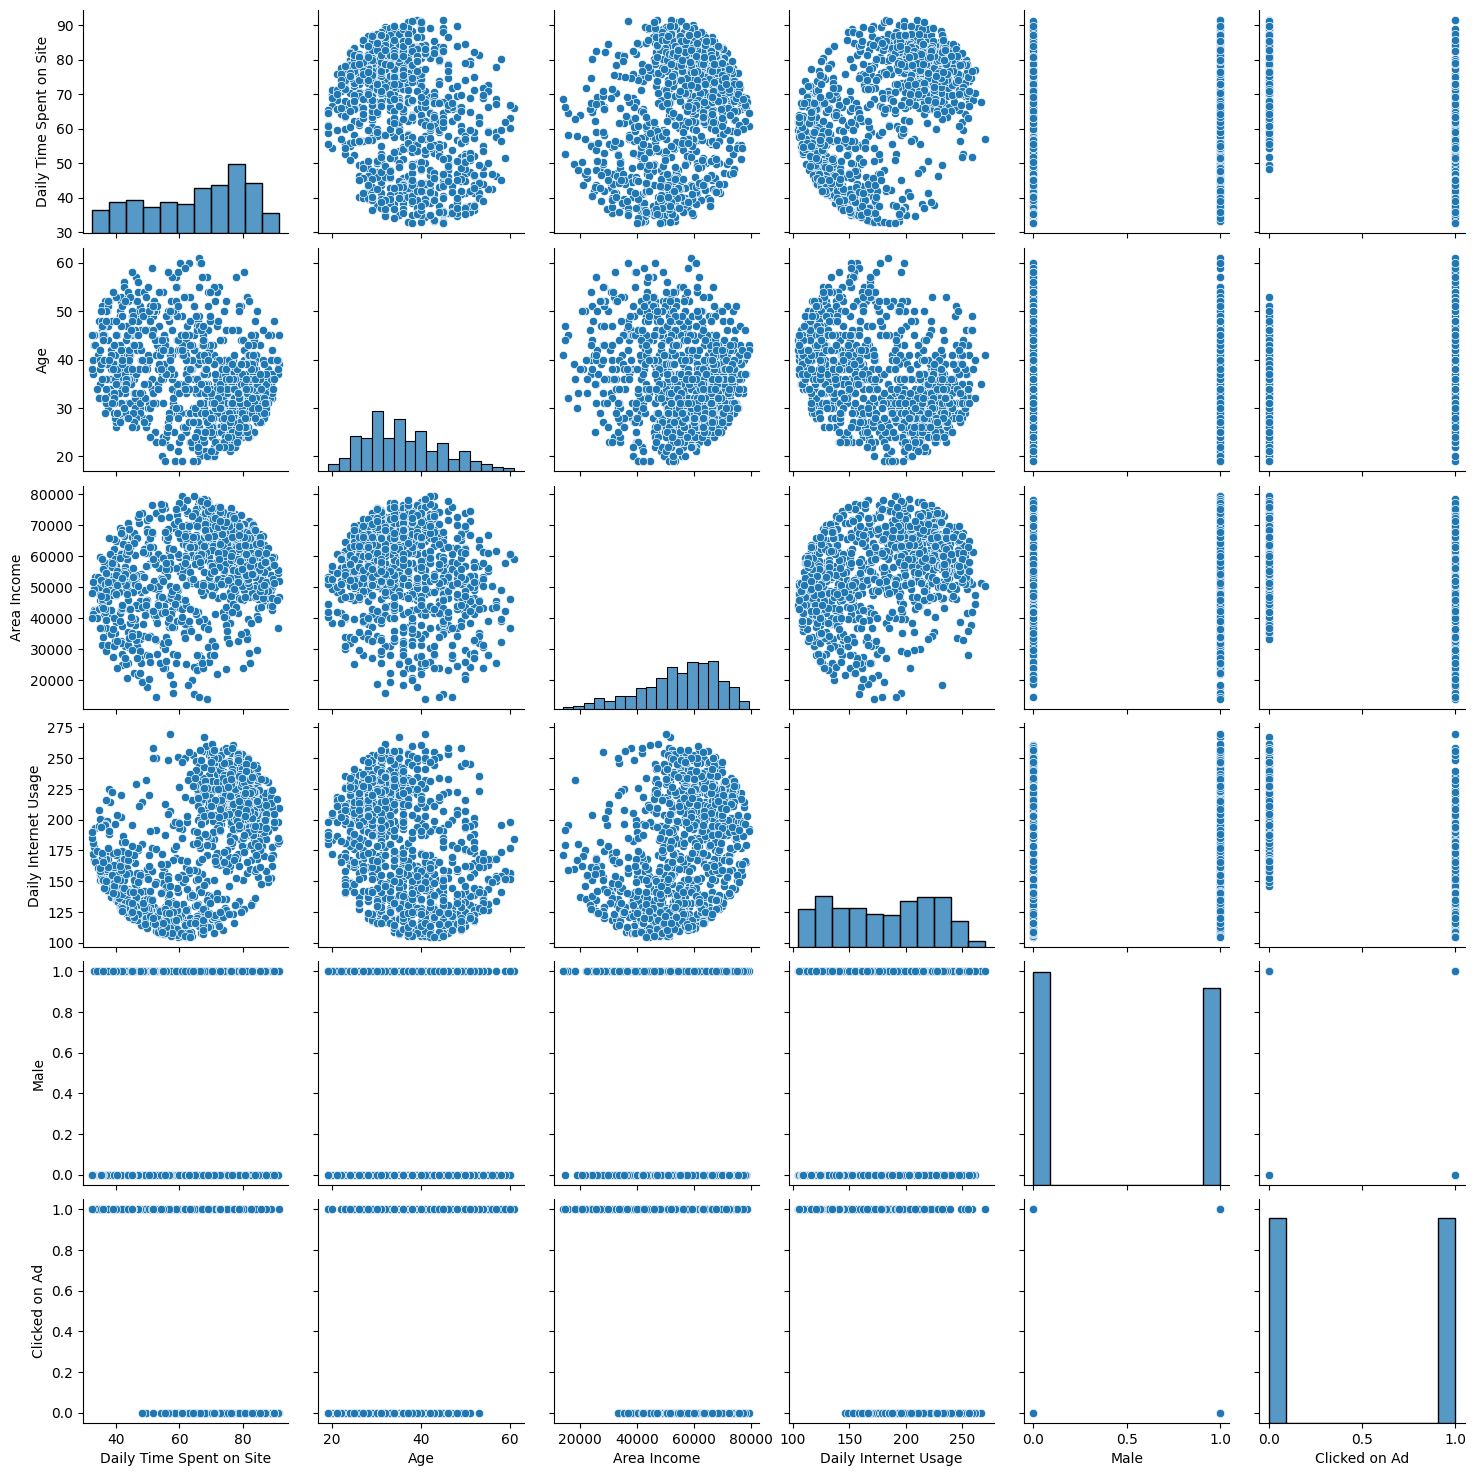

In [32]:
sns.pairplot(df);

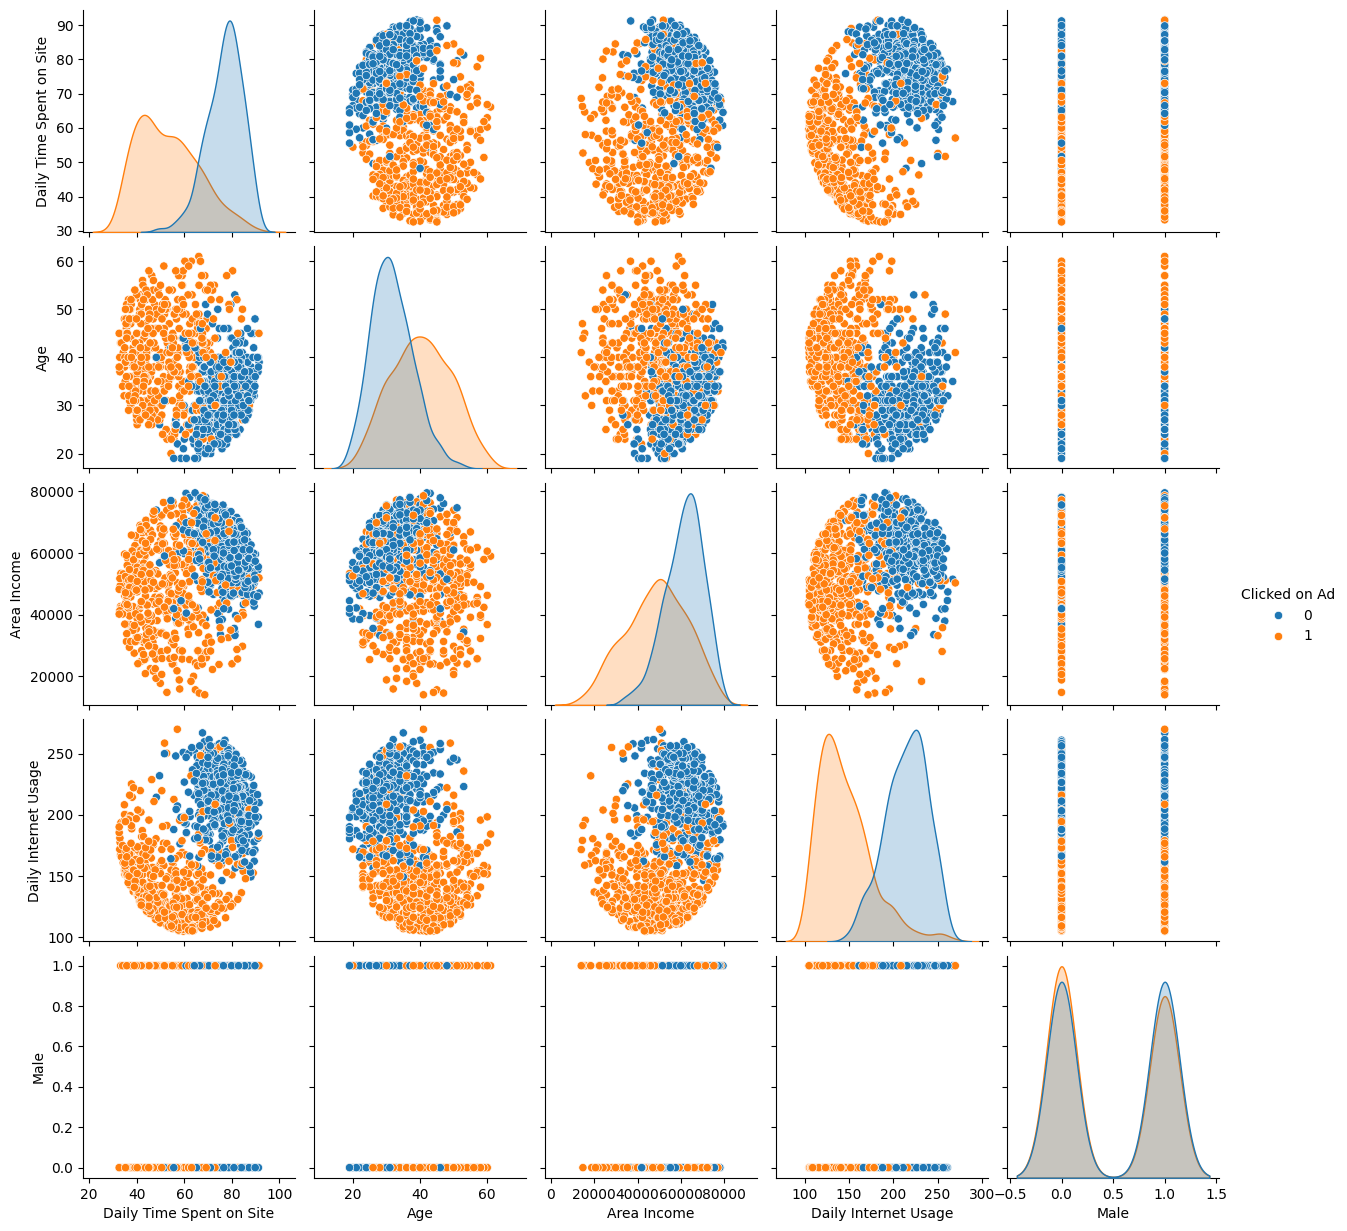

In [31]:
sns.pairplot(df, hue='Clicked on Ad');

In [14]:
df.Age.value_counts().sort_index()

Age
19     6
20     6
21     6
22    13
23    19
24    21
25    27
26    37
27    33
28    48
29    48
30    39
31    60
32    38
33    43
34    39
35    39
36    50
37    36
38    37
39    30
40    36
41    32
42    26
43    23
44    21
45    30
46    18
47    13
48    16
49    18
50    20
51    12
52    15
53    10
54     9
55     7
56     2
57     6
58     4
59     2
60     4
61     1
Name: count, dtype: int64

Primeiras impressões:
As variáveis parecem em primeira instacia não ser correlacionadas e é dificil observar correlação linear pois a nossa variável de interesse é binária.

A principio houve a impressão que pessoas mais proximas dos 60 anos não clicavam nos anuncios, mas observou-se que a amostra para pessoas nessa idade é, na verdade, muito pequena.

In [18]:
df_encoded = pd.get_dummies(df, columns=['Country','Periodo'], dtype=int)

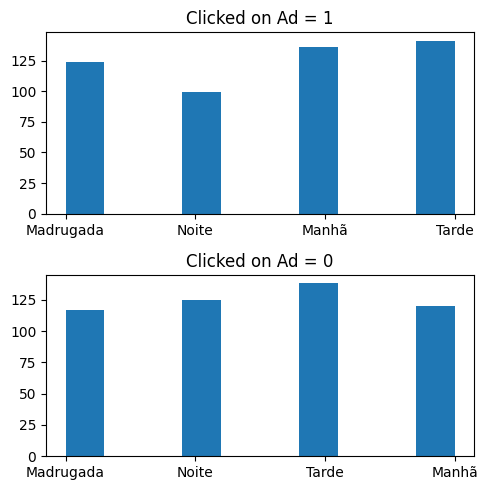

In [28]:
fig, ax = plt.subplots(2, 1, figsize=(5,5))

ax[0].hist(df[df['Clicked on Ad']==1]['Periodo'])
ax[0].set_title('Clicked on Ad = 1')

ax[1].hist(df[df['Clicked on Ad']==0]['Periodo'])
ax[1].set_title('Clicked on Ad = 0')

plt.tight_layout()
plt.show()


# Regressão Logística

Agora é hora de quebrar nossos dados em treino e teste e fitar nosso modelo.

Você terá a liberdade aqui para escolher colunas em que deseja treinar!

** Divida os dados em conjunto de treinamento e conjunto de testes usando train_test_split **

In [45]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=['Clicked on Ad'])
y = df_encoded[['Clicked on Ad']]

X_train, X_test , y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)



In [43]:
softmax_reg = LogisticRegression(max_iter=10000)
softmax_reg.fit(X_train, y_train)

c:\Users\FernandoSantos\projetos\github_pessoal\.venv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## Previsões e avaliações
** Agora preveja valores para os dados de teste. **

In [46]:
y_pred = softmax_reg.predict(X_test)

** Crie um relatório de classificação para o modelo. **

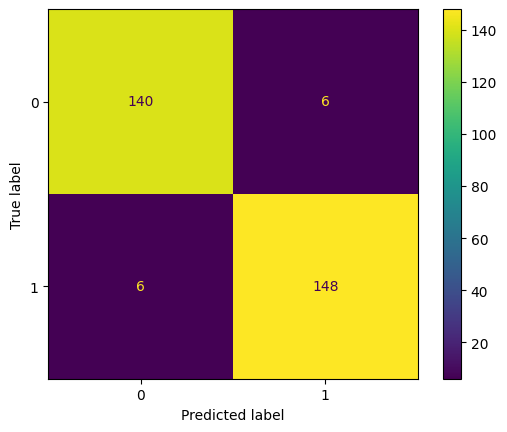

In [50]:
from sklearn.metrics import ConfusionMatrixDisplay

_ = ConfusionMatrixDisplay.from_estimator(softmax_reg, X_test, y_test)

In [52]:
coefs = pd.DataFrame(softmax_reg.coef_.T, index=X.columns, columns=['Coef'])
coefs

,Coef
Daily Time Spent on Site,-0.200429
Age,0.179904
Area Income,-0.000154
Daily Internet Usage,-0.072754
Male,-0.679013
...,...
Country_Zimbabwe,0.004667
Periodo_Madrugada,0.046489
Periodo_Manhã,0.300778
Periodo_Noite,-0.408564


In [54]:
from IPython.display import display, HTML

display(
    HTML(
        coefs.to_html(max_rows=300)
    )
)


,Coef
Daily Time Spent on Site,-0.200429
Age,0.179904
Area Income,-0.000154
Daily Internet Usage,-0.072754
Male,-0.679013
Country_Afghanistan,-0.107798
Country_Albania,0.057056
Country_Algeria,0.001478
Country_American Samoa,0.032768
Country_Andorra,0.310016
